# Task 2 — Supervised Baseline Run

**Dataset:** Microscopic Image Dataset of Plant‑Parasitic Nematodes  
**Model:** `resnet50`  
**Split (train:test):** `30:70`  
**Validation:** 10% of the training portion (group-aware where possible)  
**Epochs:** ≥ 150 (early stop allowed only after 150)



In [1]:

!pip -q install scikit-learn tqdm matplotlib thop

import os, re, time, json, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as tvm

from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_fscore_support)
from sklearn.preprocessing import label_binarize

from thop import profile

RANDOM_SEED = 42
MODEL_NAME = "resnet50"
TRAIN_RATIO = 0.3
RATIO_TAG = "30:70"
INPUT_SIZE = 224  # fixed input size for FLOPs + inference
BATCH_SIZE = 32
NUM_WORKERS = 2
EPOCHS = 150
MIN_EPOCHS = 150
PATIENCE = 8
LR = 3e-4

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything(RANDOM_SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("MODEL:", MODEL_NAME, "RATIO:", RATIO_TAG)


Device: cuda
MODEL: resnet50 RATIO: 30:70


In [2]:

#  Load dataset (auto-detect)

EXTS = {".jpg",".jpeg",".png",".bmp",".tif",".tiff",".webp"}

def find_image_root():
    candidates = []
    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        candidates += [p for p in kaggle_input.glob("**/*") if p.is_dir()]
    candidates += [Path("."), Path("/kaggle/working"), Path("/mnt/data")]
    best, best_count = None, 0
    for c in candidates:
        if not c.exists() or not c.is_dir():
            continue
        try:
            files = [p for p in c.rglob("*") if p.is_file() and p.suffix.lower() in EXTS]
        except Exception:
            continue
        if len(files) > best_count:
            best, best_count = c, len(files)
    return best, best_count

DATA_ROOT, NFOUND = find_image_root()
print("Detected DATA_ROOT:", DATA_ROOT)
print("Images found:", NFOUND)

def list_images(root: Path):
    return [p for p in root.rglob("*") if p.is_file() and p.suffix.lower() in EXTS]

image_files = list_images(DATA_ROOT)
print("Total images:", len(image_files))

def infer_label(path: Path):
    return path.parent.name

df = pd.DataFrame({
    "path": [str(p) for p in image_files],
    "label": [infer_label(p) for p in image_files],
})
print("Classes:", df["label"].nunique())
df["label"].value_counts().head()


Detected DATA_ROOT: /kaggle/input/datasets
Images found: 1016
Total images: 1016
Classes: 11


label
Genus Meloidogyne        211
Genus Hoplolaimus        151
Genus Helicotylenchus    135
Genus Hirschmaniella     130
Genus Pratylenchus       116
Name: count, dtype: int64

In [3]:

#  Group-aware splitting (leakage reduction)

def extract_group_id(path_str):
    name = Path(path_str).stem.lower()
    m = re.search(r"(id\d+|specimen\d+|s\d{1,3}|sample\d+|source\d+)", name)
    if m:
        return m.group(1)
    name2 = re.sub(r"(frame|img|image)?_?\d{2,6}$", "", name)
    name2 = re.sub(r"_[vc]\d+$", "", name2)
    return name2

df["group_id"] = df["path"].apply(extract_group_id)

labels = sorted(df["label"].unique().tolist())
label_to_idx = {l:i for i,l in enumerate(labels)}
idx_to_label = {i:l for l,i in label_to_idx.items()}
df["y"] = df["label"].map(label_to_idx)
num_classes = len(labels)

from sklearn.model_selection import GroupShuffleSplit

def make_split(df, train_ratio: float, seed: int):
    test_size = 1 - train_ratio
    groups = df["group_id"].values
    gss1 = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    trainval_idx, test_idx = next(gss1.split(df, groups=groups))
    trainval = df.iloc[trainval_idx].copy()
    test = df.iloc[test_idx].copy()

    val_size = 0.10  # 10% of the train portion
    gss2 = GroupShuffleSplit(n_splits=1, test_size=val_size, random_state=seed+1)
    train_idx, val_idx = next(gss2.split(trainval, groups=trainval["group_id"].values))
    train = trainval.iloc[train_idx].copy()
    val = trainval.iloc[val_idx].copy()
    return train.reset_index(drop=True), val.reset_index(drop=True), test.reset_index(drop=True)

seed = int(RANDOM_SEED + TRAIN_RATIO*1000)
train_df, val_df, test_df = make_split(df, TRAIN_RATIO, seed)

print("Split sizes:", len(train_df), len(val_df), len(test_df), "total:", len(train_df)+len(val_df)+len(test_df))
print("Group overlap train-test:", len(set(train_df.group_id).intersection(set(test_df.group_id))))
print("Group overlap val-test:", len(set(val_df.group_id).intersection(set(test_df.group_id))))


Split sizes: 273 31 712 total: 1016
Group overlap train-test: 0
Group overlap val-test: 0


In [4]:

# Dataset + Transforms

train_tfm = T.Compose([
    T.Resize((INPUT_SIZE, INPUT_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(0.15,0.15,0.15,0.03),
    T.ToTensor(),
])
val_tfm = T.Compose([
    T.Resize((INPUT_SIZE, INPUT_SIZE)),
    T.ToTensor(),
])

class ImgDS(Dataset):
    def __init__(self, df, tfm):
        self.df = df.reset_index(drop=True)
        self.tfm = tfm
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        p = self.df.loc[i, "path"]
        y = int(self.df.loc[i, "y"])
        img = Image.open(p).convert("RGB")
        img = self.tfm(img)
        return img, y

tr_loader = DataLoader(ImgDS(train_df, train_tfm), batch_size=BATCH_SIZE, shuffle=True,
                       num_workers=NUM_WORKERS, pin_memory=True)
va_loader = DataLoader(ImgDS(val_df, val_tfm), batch_size=BATCH_SIZE, shuffle=False,
                       num_workers=NUM_WORKERS, pin_memory=True)
te_loader = DataLoader(ImgDS(test_df, val_tfm), batch_size=BATCH_SIZE, shuffle=False,
                       num_workers=NUM_WORKERS, pin_memory=True)


In [5]:

# Model builder (torchvision pretrained)

def build_model(name: str, num_classes: int):
    name = name.lower()
    if name == "googlenet":
        m = tvm.googlenet(weights=tvm.GoogLeNet_Weights.DEFAULT)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
        return m
    if name == "mobilenet_v3_large":
        m = tvm.mobilenet_v3_large(weights=tvm.MobileNet_V3_Large_Weights.DEFAULT)
        m.classifier[-1] = nn.Linear(m.classifier[-1].in_features, num_classes)
        return m
    if name == "resnet50":
        m = tvm.resnet50(weights=tvm.ResNet50_Weights.DEFAULT)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
        return m
    if name == "resnet101":
        m = tvm.resnet101(weights=tvm.ResNet101_Weights.DEFAULT)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
        return m
    if name == "efficientnet_b0":
        m = tvm.efficientnet_b0(weights=tvm.EfficientNet_B0_Weights.DEFAULT)
        m.classifier[-1] = nn.Linear(m.classifier[-1].in_features, num_classes)
        return m
    raise ValueError("Unknown model: " + name)

model = build_model(MODEL_NAME, num_classes).to(device)
print(model.__class__.__name__)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 185MB/s] 


ResNet


In [6]:

#  GFLOPs per inference (fixed input size)

def gflops_for_model(model: nn.Module, input_size=224):
    model.eval()
    dummy = torch.randn(1,3,input_size,input_size)
    with torch.no_grad():
        macs, params = profile(model, inputs=(dummy,), verbose=False)
    gflops = (2 * macs) / 1e9  # FLOPs ≈ 2×MACs approximation
    return float(gflops), int(params)

gflops, params = gflops_for_model(model.cpu(), INPUT_SIZE)
model = model.to(device)
print("GFLOPs (approx):", round(gflops,3), "Params:", params, "Input:", INPUT_SIZE)


GFLOPs (approx): 8.263 Params: 23530571 Input: 224


In [7]:

#  Train / Eval helpers

def train_one_epoch(model, loader, opt, loss_fn):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for xb, yb in loader:
        xb = xb.to(device); yb = yb.to(device)
        opt.zero_grad()
        logits = model(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        opt.step()
        total_loss += loss.item() * yb.size(0)
        pred = logits.argmax(1)
        correct += (pred == yb).sum().item()
        total += yb.size(0)
    return total_loss/total, correct/total

@torch.no_grad()
def eval_epoch(model, loader, loss_fn):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    all_y = []
    all_probs = []
    for xb, yb in loader:
        xb = xb.to(device); yb = yb.to(device)
        logits = model(xb)
        loss = loss_fn(logits, yb)
        probs = torch.softmax(logits, dim=1)
        total_loss += loss.item() * yb.size(0)
        pred = logits.argmax(1)
        correct += (pred == yb).sum().item()
        total += yb.size(0)
        all_y.append(yb.detach().cpu().numpy())
        all_probs.append(probs.detach().cpu().numpy())
    all_y = np.concatenate(all_y) if all_y else np.array([])
    all_probs = np.concatenate(all_probs) if all_probs else np.array([])
    return total_loss/total, correct/total, all_y, all_probs

def plot_curves(history, title):
    plt.figure(figsize=(8,4))
    plt.plot(history["train_loss"], label="train_loss")
    plt.plot(history["val_loss"], label="val_loss")
    plt.title(title + " — Loss")
    plt.xlabel("epoch")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8,4))
    plt.plot(history["train_acc"], label="train_acc")
    plt.plot(history["val_acc"], label="val_acc")
    plt.title(title + " — Accuracy")
    plt.xlabel("epoch")
    plt.legend()
    plt.show()

def compute_metrics(y_true, probs, labels):
    y_pred = probs.argmax(axis=1)
    acc = accuracy_score(y_true, y_pred)

    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(labels))))
    per_class_acc = (cm.diagonal() / cm.sum(axis=1).clip(min=1)).tolist()

    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(len(labels))), zero_division=0
    )
    macro_prec = float(np.mean(prec))
    macro_rec = float(np.mean(rec))
    macro_f1 = float(np.mean(f1))

    y_bin = label_binarize(y_true, classes=list(range(len(labels))))
    roc_auc = None
    try:
        roc_auc = roc_auc_score(y_bin, probs, average="macro", multi_class="ovr")
        roc_auc = float(roc_auc)
    except Exception:
        roc_auc = None

    report = classification_report(
        y_true, y_pred, labels=list(range(len(labels))),
        target_names=labels, zero_division=0, output_dict=True
    )

    return {
        "accuracy": float(acc),
        "per_class_accuracy": per_class_acc,
        "macro_precision": macro_prec,
        "macro_recall": macro_rec,
        "macro_f1": macro_f1,
        "roc_auc_ovr_macro": roc_auc,
        "confusion_matrix": cm.tolist(),
        "classification_report": report,
    }

def plot_confusion_matrix(cm, labels, title):
    plt.figure(figsize=(8,7))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels, rotation=90)
    plt.yticks(tick_marks, labels)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

def plot_roc_curves(y_true, probs, labels, title):
    y_bin = label_binarize(y_true, classes=list(range(len(labels))))
    plt.figure(figsize=(7,6))
    for i, lab in enumerate(labels):
        try:
            fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
            plt.plot(fpr, tpr, label=lab)
        except Exception:
            continue
    plt.plot([0,1],[0,1], linestyle="--")
    plt.title(title + " — ROC (OvR)")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(fontsize=7, loc="lower right")
    plt.tight_layout()
    plt.show()

def top_confusions(cm, labels, k=10):
    cm = np.array(cm)
    cm2 = cm.copy()
    np.fill_diagonal(cm2, 0)
    pairs = []
    for i in range(cm2.shape[0]):
        for j in range(cm2.shape[1]):
            if i != j and cm2[i,j] > 0:
                pairs.append((labels[i], labels[j], int(cm2[i,j])))
    pairs.sort(key=lambda x: x[2], reverse=True)
    return pairs[:k]


ep 001: tr_acc=0.2051 va_acc=0.3548
ep 010: tr_acc=0.9487 va_acc=0.8387
ep 020: tr_acc=0.9927 va_acc=0.7742
ep 030: tr_acc=0.9927 va_acc=0.7419
ep 040: tr_acc=0.9780 va_acc=0.6129
ep 050: tr_acc=0.9963 va_acc=0.7097
ep 060: tr_acc=1.0000 va_acc=0.7742
ep 070: tr_acc=0.9963 va_acc=0.7742
ep 080: tr_acc=0.9780 va_acc=0.7097
ep 090: tr_acc=1.0000 va_acc=0.7419
ep 100: tr_acc=0.9927 va_acc=0.6774
ep 110: tr_acc=0.9963 va_acc=0.7742
ep 120: tr_acc=0.9817 va_acc=0.6774
ep 130: tr_acc=1.0000 va_acc=0.7097
ep 140: tr_acc=1.0000 va_acc=0.7419
Early stop at epoch 150 (best_val=0.9032)
Train time (sec): 857.55
Test time (sec): 11.86
Test accuracy: 0.7191 Macro-F1: 0.6516 AUC: 0.9305995454250613


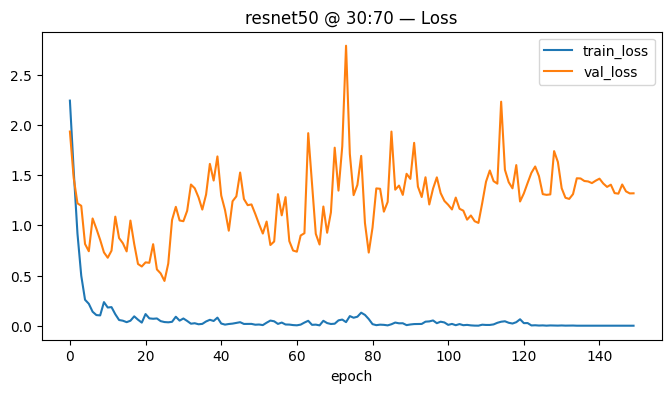

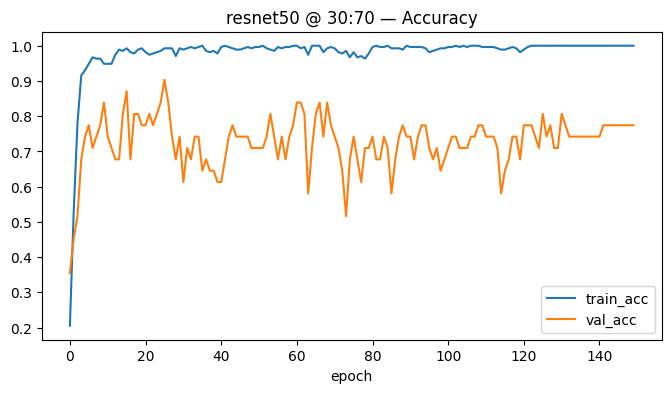

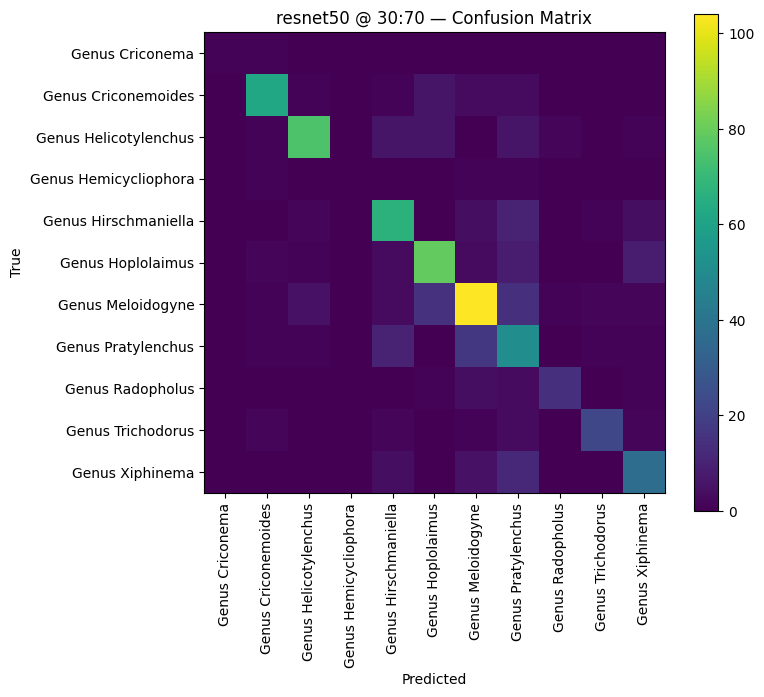

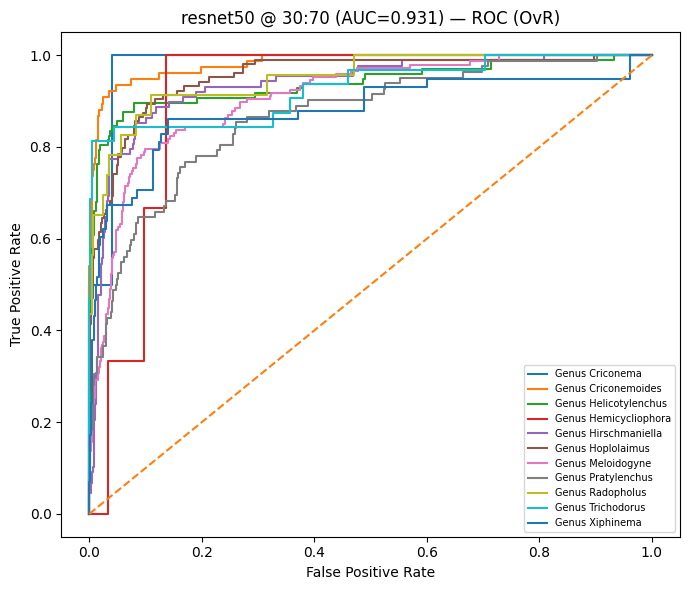

Top confusions: [('Genus Pratylenchus', 'Genus Meloidogyne', 17), ('Genus Meloidogyne', 'Genus Hoplolaimus', 15), ('Genus Meloidogyne', 'Genus Pratylenchus', 14), ('Genus Xiphinema', 'Genus Pratylenchus', 12), ('Genus Hirschmaniella', 'Genus Pratylenchus', 10), ('Genus Pratylenchus', 'Genus Hirschmaniella', 10), ('Genus Hoplolaimus', 'Genus Pratylenchus', 8), ('Genus Hoplolaimus', 'Genus Xiphinema', 8), ('Genus Criconemoides', 'Genus Hoplolaimus', 6), ('Genus Helicotylenchus', 'Genus Hirschmaniella', 6)]


In [8]:

#  Train (>=150 epochs) + Evaluate on test

loss_fn = nn.CrossEntropyLoss()
opt = torch.optim.AdamW(model.parameters(), lr=LR)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val = -1
best_state = None
bad = 0

t0 = time.time()
for ep in range(EPOCHS):
    tr_loss, tr_acc = train_one_epoch(model, tr_loader, opt, loss_fn)
    va_loss, va_acc, _, _ = eval_epoch(model, va_loader, loss_fn)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)

    if va_acc > best_val:
        best_val = va_acc
        best_state = {k:v.detach().cpu() for k,v in model.state_dict().items()}
        bad = 0
    else:
        bad += 1

    if (ep+1) >= MIN_EPOCHS and bad >= PATIENCE:
        print(f"Early stop at epoch {ep+1} (best_val={best_val:.4f})")
        break

    if (ep+1) % 10 == 0 or ep == 0:
        print(f"ep {ep+1:03d}: tr_acc={tr_acc:.4f} va_acc={va_acc:.4f}")

train_time = time.time() - t0
print("Train time (sec):", round(train_time,2))

if best_state is not None:
    model.load_state_dict(best_state)

t1 = time.time()
_, test_acc, y_true, probs = eval_epoch(model, te_loader, loss_fn)
test_time = time.time() - t1
print("Test time (sec):", round(test_time,2))

metrics = compute_metrics(y_true, probs, labels)
print("Test accuracy:", round(metrics["accuracy"],4), "Macro-F1:", round(metrics["macro_f1"],4), "AUC:", metrics["roc_auc_ovr_macro"])

plot_curves(history, f"{MODEL_NAME} @ {RATIO_TAG}")
plot_confusion_matrix(np.array(metrics["confusion_matrix"]), labels, f"{MODEL_NAME} @ {RATIO_TAG} — Confusion Matrix")
if metrics["roc_auc_ovr_macro"] is not None:
    plot_roc_curves(y_true, probs, labels, f"{MODEL_NAME} @ {RATIO_TAG} (AUC={metrics['roc_auc_ovr_macro']:.3f})")

print("Top confusions:", top_confusions(metrics["confusion_matrix"], labels, k=10))
